In [33]:
import numpy as np
import torch
import gpytorch
from matplotlib import pyplot as plt
import pandas as pd
from scipy import interpolate
import random
from scipy.interpolate import interp1d

In [21]:
putts = pd.read_csv("/Users/federicadomecq/Documents/golfModeL47-1/PART 1/broadiedata/strokes_on_green_feet_broadie.csv")
columns = putts.columns
print(columns)

Index(['Distance (feet)', 'Green'], dtype='object')


# Interpolating expected putts

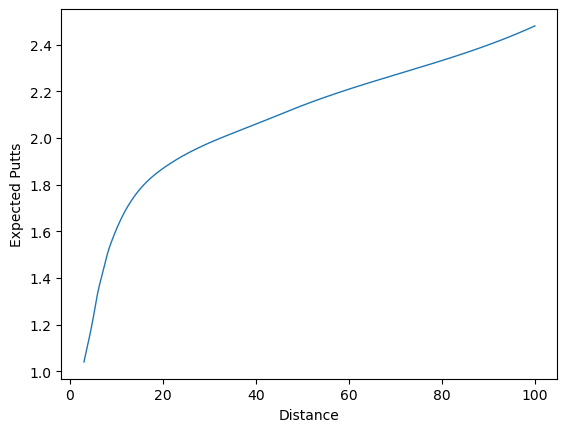

In [22]:
dist, avg_putts = putts["Distance (feet)"], putts["Green"]
expected_putts = interpolate.interp1d(dist, avg_putts, kind = "cubic", fill_value = "extrapolate")
x_true = np.linspace(min(dist), max(dist) + 10, 500)
y_true = expected_putts(x_true)
plt.plot(x_true, y_true, label = "true function", linewidth = 1 )
plt.xlabel("Distance")
plt.ylabel("Expected Putts")
plt.show()

# Simulating Fake Data

Generating data. The average number of events in a PGA tour season is 39. So generating 35 different observations max at any point... fewer observations the longer the putt.
Simulating recorded tournament average putts at different distances (feet).
For each distance $d\in [1,100]$ I'm going to generate a number of samples:
- $n_d = 35, d \leq 30 $
- $n_d$ decreases smoothly as $d \to 100$

Defining sampling frequency:

Text(0, 0.5, 'Average putts to hole out')

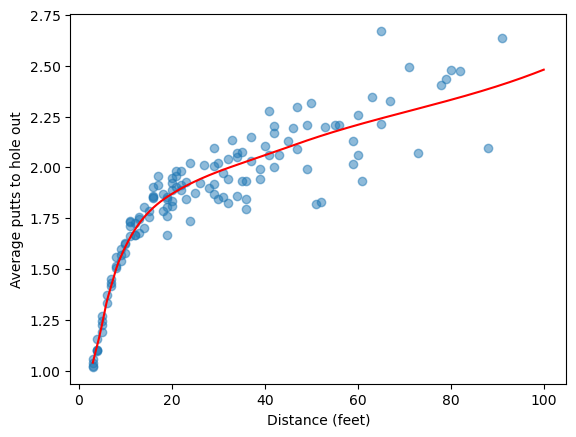

In [23]:
random.seed(47)
def samples_at(dist):
        decay_rate = 0.04  # tweak this!
        p = 1 / (1 + np.exp(decay_rate * (dist - 20))) 
        return np.random.binomial(n=5, p=p)
    
def noise_sd(d):
    return min(0.0028 * d + 0.02, 1.2)

simulated_averages = []
for distance in range(3,100):
    current_expected = expected_putts(distance)
    current_variance = noise_sd(d = distance)
    n_samples = samples_at(distance)
    for samples in range(n_samples):
        simulated_averages.append((distance, np.random.normal(current_expected, current_variance)))

xs_sim_distance = []
ys_sim_average = []

for pair in simulated_averages:
    distance, average = pair
    xs_sim_distance.append(distance)
    ys_sim_average.append(average)

plt.scatter(xs_sim_distance, ys_sim_average, alpha = .5)
plt.plot(x_true, y_true, color = "red")
plt.xlabel("Distance (feet)")
plt.ylabel("Average putts to hole out")

# Implementing GPR using GPyTorch - but changing diagonal in Covariance Matrix

## Using Empirical Variance

### Computing empirical variance for each distance with more than 2 observations, interpolating between

In [79]:
# Stacking the observations into columns -> create dataframe to groupby and compute empirical variance
samples = np.column_stack((xs_sim_distance, ys_sim_average))
average_puttsdf = pd.DataFrame(samples, columns = ["distance", "putts"])

# Computed empirical values
grouped_averages = average_puttsdf.groupby("distance")["putts"]
emp_variances = grouped_averages.var()

known_distances = np.array(emp_variances.index)
known_variances = np.array(emp_variances.values)

# Interpolation functions for missing variances
variance_interp = interp1d(
    known_distances,
    known_variances,
    kind = "linear",
)

Y_var = variance_interp(xs_sim_distance)[:, None]


NaNs in Y_var: True
Negatives in Y_var: False
Min Y_var: nan
Max Y_var: nan
Mean Y_var: nan


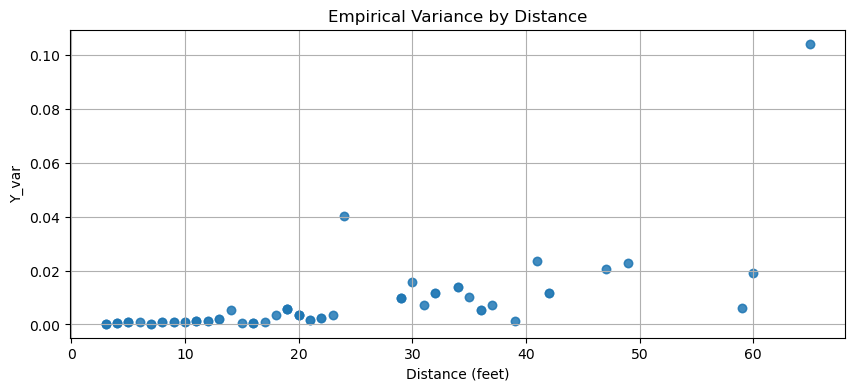

In [60]:

import numpy as np
import matplotlib.pyplot as plt

print("NaNs in Y_var:", np.isnan(Y_var).any())
print("Negatives in Y_var:", (Y_var < 0).any())
print("Min Y_var:", np.min(Y_var))
print("Max Y_var:", np.max(Y_var))
print("Mean Y_var:", np.mean(Y_var))

plt.figure(figsize=(10, 4))
plt.scatter(xs_sim_distance, Y_var, alpha=0.6)
plt.title("Empirical Variance by Distance")
plt.xlabel("Distance (feet)")
plt.ylabel("Y_var")
plt.grid(True)
plt.show()

## Defining the model with fixed noise gaussian

In [80]:
Y_var = np.clip(Y_var, 0.002, None)

# converting data to torch tensors
train_x = torch.tensor(xs_sim_distance).unsqueeze(1).float()
train_y = torch.tensor(ys_sim_average).float()
train_noise = torch.tensor(Y_var.flatten(),  dtype=torch.float32)

likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(noise = train_noise, learn_additional_noise=False)


class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        rbf = gpytorch.kernels.RBFKernel()
        rbf.lengthscale = 30.0
        self.covar_module = gpytorch.kernels.ScaleKernel(rbf)

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

gpmodel = GPModel(train_x, train_y, likelihood = likelihood)

# Training the model

In [81]:
# fixed noise GP
optimiser = torch.optim.Adam(gpmodel.parameters(), lr = 0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gpmodel)


gpmodel.train()
likelihood.train()

# output = gpmodel(train_x)
# loss = -mll(output, train_y)

for i in range(100):
    optimiser.zero_grad()
    output = gpmodel(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimiser.step()

NanError: cholesky_cpu: 26 of 17424 elements of the torch.Size([132, 132]) tensor are NaN.

In [77]:
# Replace NaNs, clip to avoid 0s or negatives
Y_var = np.nan_to_num(Y_var, nan=0.005)
Y_var = np.clip(Y_var, 0.002, 1.0)

# Convert data to torch tensors
train_x = torch.tensor(xs_sim_distance).unsqueeze(1).float()
train_y = torch.tensor(ys_sim_average).float()
train_noise = torch.tensor(Y_var, dtype=torch.float32)

# Use FixedNoiseLikelihood
likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(
    noise=train_noise,
    learn_additional_noise=False
)

class GPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(lengthscale_constraint=gpytorch.constraints.Interval(10.0, 100.0))
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Model
gpmodel = GPModel(train_x, train_y, likelihood)

# Train
gpmodel.train()
likelihood.train()

optimizer = torch.optim.Adam(gpmodel.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, gpmodel)

for i in range(100):
    optimizer.zero_grad()
    output = gpmodel(train_x)
    loss = -mll(output, train_y)
    loss.backward()
    optimizer.step()


In [78]:
gpmodel.eval()
likelihood.eval()

# Generate test inputs
test_x = torch.linspace(train_x.min(), train_x.max(), 300).unsqueeze(1)

# Prior samples
with torch.no_grad():
    mean_prior = gpmodel.mean_module(test_x)
    cov_prior = gpmodel.covar_module(test_x).evaluate()
    prior_dist = gpytorch.distributions.MultivariateNormal(mean_prior, cov_prior)
    prior_samples = prior_dist.rsample(torch.Size([5]))

plt.figure(figsize=(10,6))
for i in range(5):
    plt.plot(test_x.numpy(), prior_samples[i].numpy(), label=f"Sample {i+1}", alpha=0.6)
plt.title("Samples from Prior Distribution")
plt.xlabel("Distance")
plt.ylabel("Function Value")
plt.grid(True)
plt.legend()
plt.show()

# Posterior samples
with torch.no_grad():
    posterior_dist = gpmodel(test_x)
    posterior_samples = posterior_dist.rsample(torch.Size([5]))

plt.figure(figsize=(10,6))
for i in range(5):
    plt.plot(test_x.numpy(), posterior_samples[i].numpy(), label=f"Sample {i+1}", alpha=0.6)
plt.scatter(train_x.numpy(), train_y.numpy(), color='black', s=10, alpha=0.6, label="Training data")
plt.title("Samples from Posterior")
plt.xlabel("Distance")
plt.ylabel("Function Value")
plt.grid(True)
plt.legend()
plt.show()

# Posterior predictive distribution
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    preds = likelihood(gpmodel(test_x))
    mean = preds.mean
    lower, upper = preds.confidence_region()

plt.figure(figsize=(10,6))
plt.plot(test_x.numpy(), mean.numpy(), 'b', label='Posterior Mean')
plt.fill_between(test_x.squeeze().numpy(), lower.numpy(), upper.numpy(), alpha=0.2, label='95% Confidence Interval')
plt.scatter(train_x.numpy(), train_y.numpy(), color='black', s=10, alpha=0.5, label='Training data')
plt.title("Posterior Predictive Distribution")
plt.xlabel("Distance")
plt.ylabel("Putts to Hole Out")
plt.legend()
plt.grid(True)
plt.show()


_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 3 is not positive-definite).